In [7]:
import matplotlib.pyplot as plt
import numpy as np

import freq_statespace as fss

import best_linear_approximation as bla

raw_data = np.load("closed_loop_controller_id.npz")

r = raw_data["r"][:, [1], :]
u = raw_data["u"][:, [1], :, :]
e = raw_data["e"][:, [1], :, :]

# select onl

print(raw_data["message"])

r -= np.mean(r, axis=(0, 2), keepdims=True)
e -= np.mean(e, axis=(0, 2, 3), keepdims=True)
u -= np.mean(u, axis=(0, 2, 3), keepdims=True)

fs = float(raw_data["fs"])

G_bla = bla.robust.closed_loop(r=r, u=e, y=u, fs=fs, independent_subexperiments=True)

id_data_c = fss.create_data_object_from_bla(G_bla)

print(G_bla.spectra.Y.total_equation_error.as_percentage)
print(G_bla.spectra.Y.total.as_percentage)
print(G_bla.spectra.Y.noise.as_percentage)

Deployed experiment 75938075: 3 rev/s setpoint + 0.5 rev/s RMS multisine (0.09765625 to 9.9609375 Hz), load amplitude 10%; 10 realizations x 4 periods at 100 Hz.
Detected 102 excited frequency bins from 9.77e-02 Hz to 9.96 Hz; every bin in that interval is excited (full multisine).
[20.58761948]
[39.4385895]
[45.67750335]


<div align="center">
  <img src="https://github.com/merijnfloren/freq-statespace/raw/main/docs/model_structure.svg" width="500px" />
</div>


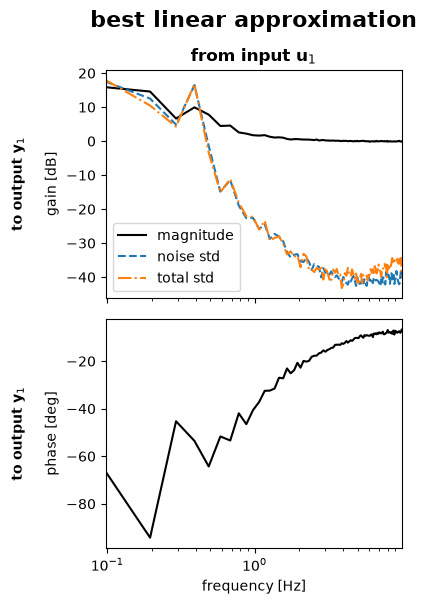

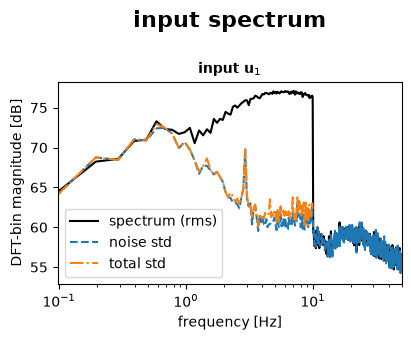

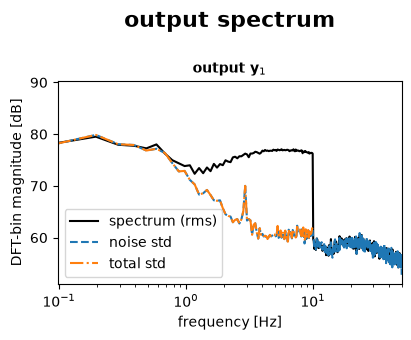

In [8]:


from bla_analysis import plot_bla_analysis

plot_bla_analysis(G_bla)


In [9]:
# Step 1: BLA estimation
nx = 1  # state dimension
bla_c_right = fss.lin.subspace_id(id_data_c, nx)
bla_c_right = fss.lin.optimize(bla_c_right, id_data_c)


norm = fss.Normalizer(u_mean=0, u_std=1, y_mean=0, y_std=1)
bla_c_left = fss.ModelBLA(A=np.reshape(1, (1, 1)), B_u=np.reshape(1, (1, 1)), C_y=np.reshape(0.05, (1, 1)), D_yu=np.reshape(1.025, (1, 1)), norm=norm, ts=1/fs)


=============== Frequency-domain subspace identification ===============
BLA simulation error: 20.02%.

=========================== BLA optimization ===========================
Starting iterative optimization...
    Iter 1 | loss = 3.4390e+00
    Iter 2 | loss = 3.4390e+00
    Iter 3 | loss = 3.4293e+00
    Iter 4 | loss = 3.4289e+00
    Iter 5 | loss = 3.4288e+00
    Iter 6 | loss = 3.4288e+00
    Iter 7 | loss = 3.4288e+00
    Iter 8 | loss = 3.4288e+00
    Iter 9 | loss = 3.4288e+00
    Iter 10 | loss = 3.4288e+00
Optimization completed in 0.02s (10 iterations, 0.78ms/iter).

BLA simulation error: 114.37%.



In [16]:
print(bla_c_right.norm.y_std)

[98.19257288]


1


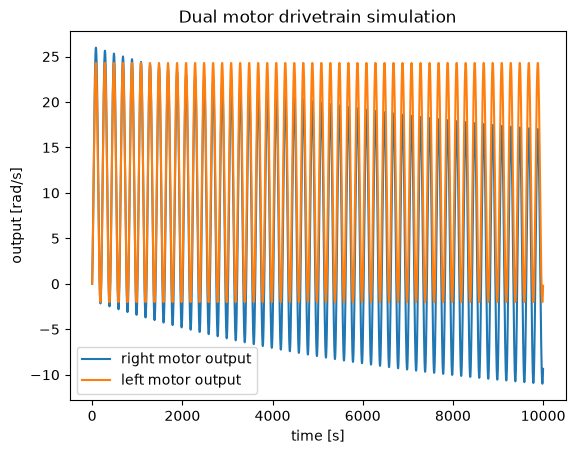

In [17]:
t  = np.arange(0, 100, 1/fs)
u_c = 7 * np.sin(2 * np.pi * 0.5 * t)

print(bla_c_right.B_u.shape[1])

y_right_c = bla_c_right.simulate(u_c)[0]
y_left_c = bla_c_left.simulate(u_c)[0]

# %matplotlib qt5
plt.figure()
# plt.plot(e[:,0,0,0], label="input")
plt.plot(y_right_c, label="right motor output")
plt.plot(y_left_c, label="left motor output")
plt.xlabel("time [s]")
plt.ylabel("output [rad/s]")
plt.title("Dual motor drivetrain simulation")
plt.legend()
plt.show()


Deployed experiment 37854498: 3 rev/s setpoint. 30% RMS feedforward multisine (0.09765625 to 9.9609375 Hz), load amplitude 10%; 10 realizations x 4 periods at 100 Hz.


Detected 102 excited frequency bins from 9.77e-02 Hz to 9.96 Hz; every bin in that interval is excited (full multisine).


/home/merijn/Documents/freq-statespace/.venv/lib/python3.12/site-packages/best_linear_approximation/_argument_preparation.py:132: PossiblePeriodMismatchWarning: The relative spectral mismatch between all 3 adjacent period pairs exceeds the threshold of 2.50%. This may indicate transients, drift, changing excitation, or period-alignment issues. Aggregated relative differences: [29.08%, 25.61%, 24.99%].
  _warn_if_output_spectra_mismatch(y, max_bin)


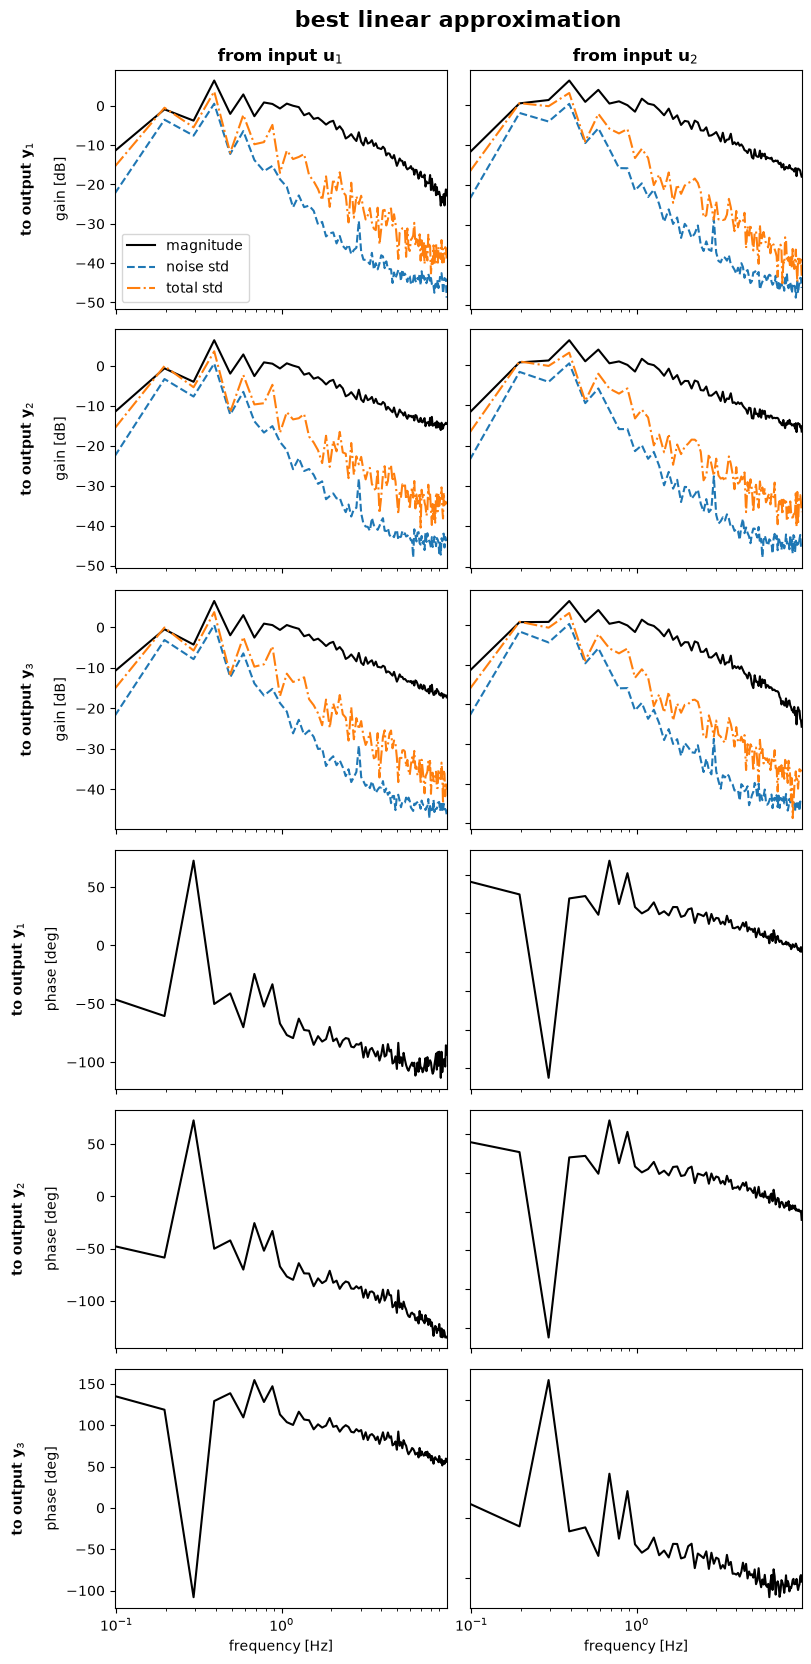

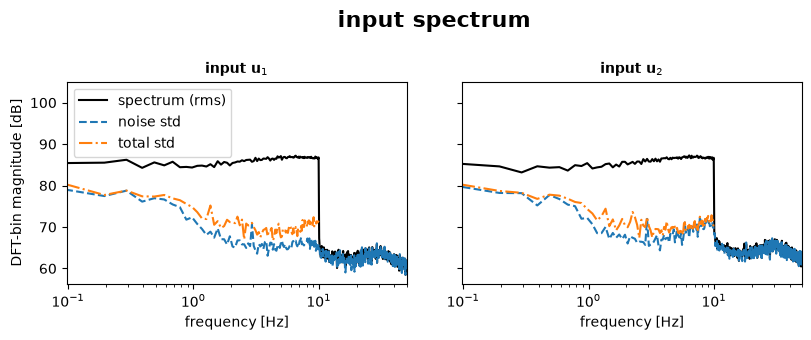

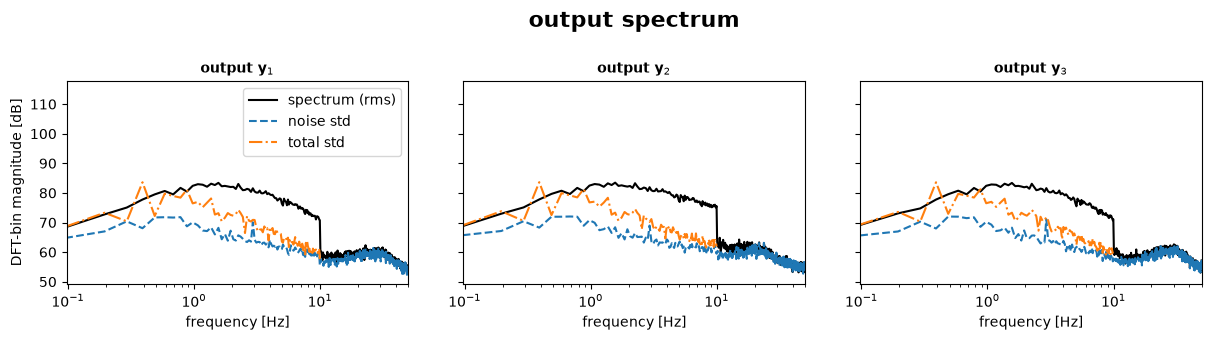

In [7]:
raw_data = np.load("closed_loop_plant_id_100Nm_load.npz")

r_train, r_test = raw_data["r"][..., :8], raw_data["r"][..., 8:]
u_train, u_test = raw_data["u"][..., :8, :], raw_data["u"][..., 8:, :]
y_train, y_test = raw_data["y"][..., :8, :], raw_data["y"][..., 8:, :]

# select onl

print(raw_data["message"])


G_bla = bla.robust.closed_loop(r=r_train, u=u_train, y=y_train, fs=fs, independent_subexperiments=True)

plot_bla_analysis(G_bla)

id_data_p = fss.create_data_object_from_bla(G_bla)

In [8]:
# Step 1: BLA estimation
nx = 3  # state dimension
bla_p = fss.lin.subspace_id(id_data_p, nx)
bla_p = fss.lin.optimize(bla_p, id_data_p)


=============== Frequency-domain subspace identification ===============
BLA simulation error:
    output 1: 74.83%.
    output 2: 71.11%.
    output 3: 66.27%.

=========================== BLA optimization ===========================
Starting iterative optimization...
    Iter 1 | loss = 4.3535e+00
    Iter 2 | loss = 4.3535e+00
    Iter 3 | loss = 2.9811e+00
    Iter 4 | loss = 2.4472e+00
    Iter 5 | loss = 2.2127e+00
    Iter 6 | loss = 2.1125e+00
    Iter 7 | loss = 2.1024e+00
    Iter 8 | loss = 2.0999e+00
    Iter 9 | loss = 2.0976e+00
    Iter 10 | loss = 2.0968e+00
    Iter 11 | loss = 2.0968e+00
    Iter 12 | loss = 2.0968e+00
    Iter 13 | loss = 2.0968e+00
    Iter 14 | loss = 2.0968e+00
    Iter 15 | loss = 2.0968e+00
    Iter 16 | loss = 2.0968e+00
    Iter 17 | loss = 2.0968e+00
    Iter 18 | loss = 2.0968e+00
    Iter 19 | loss = 2.0968e+00
    Iter 20 | loss = 2.0968e+00
    Iter 21 | loss = 2.0968e+00
Optimization completed in 0.06s (21 iterations, 1.56ms/iter).

BLA 